<a href="https://colab.research.google.com/github/keshavbaviskar33-sudo/AI-Credit-Analyst-Copilot/blob/main/notebooks/01_initial_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.47M/4.47M [00:00<00:00, 111MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/versions/3


In [2]:
import pandas as pd
import numpy as np
import os # Import the os module to list directory contents

# List the contents of the directory to verify file names
print(f"Contents of {path}: {os.listdir(path)}")

# The original code was trying to read 'data.csv', but a FileNotFoundError occurred.
# Based on the Kaggle dataset, 'bankruptcy.csv' is a more likely primary data file.
# Correcting the filename based on os.listdir output.
df = pd.read_csv(os.path.join(path, "american_bankruptcy.csv"))
df.head()

Contents of /root/.cache/kagglehub/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/versions/3: ['american_bankruptcy.csv']


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [3]:
df.shape

(78682, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  78682 non-null  object 
 1   status_label  78682 non-null  object 
 2   year          78682 non-null  int64  
 3   X1            78682 non-null  float64
 4   X2            78682 non-null  float64
 5   X3            78682 non-null  float64
 6   X4            78682 non-null  float64
 7   X5            78682 non-null  float64
 8   X6            78682 non-null  float64
 9   X7            78682 non-null  float64
 10  X8            78682 non-null  float64
 11  X9            78682 non-null  float64
 12  X10           78682 non-null  float64
 13  X11           78682 non-null  float64
 14  X12           78682 non-null  float64
 15  X13           78682 non-null  float64
 16  X14           78682 non-null  float64
 17  X15           78682 non-null  float64
 18  X16           78682 non-nu

In [5]:
df.isnull().sum()

,0
company_name,0
status_label,0
year,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0


In [6]:
df['status_label'].value_counts(normalize=True)

,proportion
status_label,
alive,0.933657
failed,0.066343


In [7]:
df['company_name'].nunique()

8971

Interest coverage not computed — no interest expense field in source data


In [8]:
df['current_ratio'] = df['X1'] / df['X14']
df['debt_to_equity'] = df['X11']/(df['X10']-df['X17'])
df['net_profit_margin']= df['X6']/df['X16']
df[['current_ratio','debt_to_equity','net_profit_margin']].head()

,current_ratio,debt_to_equity,net_profit_margin
0,3.120983,0.531485,0.034328
1,3.874697,0.529044,0.021196
2,2.902063,0.701723,-0.092277
3,1.947253,0.558185,-0.020467
4,3.292707,0.824260,0.005375


In [9]:
df['current_ratio'].isna().sum()

np.int64(0)

In [10]:
df['debt_to_equity'].isna().sum()

np.int64(0)

In [11]:
df['net_profit_margin'].isna().sum()

np.int64(0)

In [12]:
np.isinf(df[['current_ratio','debt_to_equity','net_profit_margin']]).sum()

,0
current_ratio,0
debt_to_equity,2
net_profit_margin,0


In [13]:
df[np.isinf(df['debt_to_equity'])][['company_name','year','status_label']]

,company_name,year,status_label
64769,C_6980,2002,failed
69826,C_7561,2007,alive


In [14]:
df['debt_to_equity'][~np.isinf(df['debt_to_equity'])].max()

75264.24999964063

In [15]:
df['debt_to_equity'].sort_values(ascending=False).head(15)

,debt_to_equity
64769,inf
69826,inf
61872,7.526425e+04
22895,1.338000e+04
61093,1.188877e+04
59863,4.462850e+03
22786,3.526545e+03
10750,3.096268e+03
70097,2.640889e+03
19452,2.170615e+03


Changing the inf values of debt to equity ratio to 99%ile winsorized value


In [16]:
cap = df['debt_to_equity'][~np.isinf(df['debt_to_equity'])].quantile(0.99)
df['debt_to_equity'] = df['debt_to_equity'].replace([np.inf, -np.inf], cap)

In [17]:
print(cap)

10.25873829219188


In [18]:
np.isinf(df[['current_ratio','debt_to_equity','net_profit_margin']]).sum()

,0
current_ratio,0
debt_to_equity,0
net_profit_margin,0


Step 1: get the failure year per company (NaN if the company never fails)

In [19]:
failure_year = (df[df['status_label']=='failed'].groupby('company_name'))['year'].min()

Step 2: map failure_year back onto every row of df

In [20]:
df['failure_year'] = df['company_name'].map(failure_year)

Step 3: years until failure (NaN stays NaN for companies that never fail)

In [21]:
df['years_until_failure'] = df['failure_year'] - df['year']

Step 4: build the target
NaN comparisons (>=, <=) always evaluate to False in pandas/numpy,

*   NaN comparisons (>=, <=) always evaluate to False in pandas/numpy,
*   so never-failed companies automatically get target = 0 — no special-casing needed

### * **Note - Marking 0,1,2 as target because according to Altran Z- data probabilty of predicting falls drastically after 2nd year before failure**




   



In [22]:
df['target'] = (
    (df['years_until_failure'] >= 0) & (df['years_until_failure'] <= 2)
).astype(int)

sanity checks

In [23]:
print(df['target'].value_counts(normalize=True))
print(df[df['company_name'].isin(failure_year.index[:1])][
    ['company_name','year','status_label','failure_year','years_until_failure','target']
])

target
0    0.99226
1    0.00774
Name: proportion, dtype: float64
      company_name  year status_label  failure_year  years_until_failure  \
12240       C_1020  1999       failed        1999.0                  0.0   
12241       C_1020  2000       failed        1999.0                 -1.0   
12242       C_1020  2001       failed        1999.0                 -2.0   
12243       C_1020  2002       failed        1999.0                 -3.0   
12244       C_1020  2003       failed        1999.0                 -4.0   
12245       C_1020  2004       failed        1999.0                 -5.0   

       target  
12240       1  
12241       0  
12242       0  
12243       0  
12244       0  
12245       0  


In [24]:
print(df[df['company_name'].isin(failure_year.index[1:2])][
    ['company_name','year','status_label','failure_year','years_until_failure','target']
])

      company_name  year status_label  failure_year  years_until_failure  \
12597       C_1046  1999       failed        1999.0                  0.0   
12598       C_1046  2000       failed        1999.0                 -1.0   
12599       C_1046  2001       failed        1999.0                 -2.0   
12600       C_1046  2002       failed        1999.0                 -3.0   
12601       C_1046  2006       failed        1999.0                 -7.0   
12602       C_1046  2007       failed        1999.0                 -8.0   
12603       C_1046  2008       failed        1999.0                 -9.0   
12604       C_1046  2009       failed        1999.0                -10.0   
12605       C_1046  2010       failed        1999.0                -11.0   
12606       C_1046  2011       failed        1999.0                -12.0   
12607       C_1046  2012       failed        1999.0                -13.0   
12608       C_1046  2013       failed        1999.0                -14.0   
12609       

## Target Label Construction — Handling Persistent Failure Status

**Initial approach:** labeled target=1 if a row fell within 1-2 years before
a company's first `failed` year, else 0.

**Bug found:** `status_label` is not a one-time event — once a company is marked
`failed`, every subsequent row for that company (however many years later) also
shows `failed`. Initial target logic silently mislabeled these "zombie"
post-failure rows as target=0 (safe), since years_until_failure went negative
for them, and my range check (0 <= years_until_failure <= 2) excluded negatives
without me realizing what that excluded.

**Why this mattered:** these rows represent an already-collapsed company still
appearing in the dataset (possibly delisted/inactive), not a "healthy" example.
Leaving them labeled 0 would have taught the model that already-failed companies'
financials look like safe companies — actively harmful noise, not just unused data.

**Fix:** filter out all rows where years_until_failure < 0 (post-failure rows)
before building the target, keeping NaN (never-failed) rows correctly via
pandas' NaN-comparison behavior.

**Result:** 78,682 → 74,071 rows (4,611 zombie rows removed, ~5.9% of dataset).
Target positive rate: 0.82% (up slightly from 0.77%, still heavily imbalanced —
will need class-imbalance handling in model training).

In [25]:
print(len(df))
df = df[~(df['years_until_failure'] < 0)] # Negation true ko false and false ko true karta hai. And df sirf true waalon ko rakhta hai . Null ka case also hadled
print(len(df))

78682
74071


In [26]:
df['target'] = (
    (df['years_until_failure'] >= 0) & (df['years_until_failure'] <= 2)
).astype(int)

In [27]:
print(df['target'].value_counts(normalize=True))
print(df[df['company_name'].isin(failure_year.index[:3])][
    ['company_name','year','status_label','failure_year','years_until_failure','target']
])

target
0    0.991778
1    0.008222
Name: proportion, dtype: float64
      company_name  year status_label  failure_year  years_until_failure  \
12240       C_1020  1999       failed        1999.0                  0.0   
12597       C_1046  1999       failed        1999.0                  0.0   
12741       C_1058  2010       failed        2010.0                  0.0   

       target  
12240       1  
12597       1  
12741       1  


## Train/Validation/Test Split

Investigated year distribution before choosing a split strategy. Found:
- Row counts decline steadily from 1999 (5,308) to 2018 (2,687) — mild trend, not alarming.
- Failure counts are heavily front-loaded: 1999 alone has 380 failures (~64% of all
  failures in the dataset), dropping sharply in every year after. Likely a left-censoring
  artifact — companies already in financial distress before the dataset's start get
  captured as failures right at the first observable year, rather than 1999 being a
  uniquely bad economic year.

Given this concentration, picking an arbitrary cutoff risked either overloading training
with 1999's failures or leaving the test set with almost no positive examples.

**Decision:** adopted the standard split already published with this dataset
(train: 1999-2011, validation: 2012-2014, test: 2015-2018), rather than inventing a
custom cutoff. This keeps results comparable to published benchmarks and avoids
introducing a new, unvalidated split under time pressure.

**Group-leakage check:** verified company overlap across the three periods
(train∩val: 3,115, train∩test: 2,517, val∩test: 3,096 companies). Given the dataset
uses only 3 raw financial ratios as features (not high-capacity models or dozens of
engineered features), the risk of the model memorizing company identity rather than
learning generalizable financial patterns is low. Accepted the overlap rather than
enforcing strict company-level separation, consistent with the original dataset's own
published split methodology.


In [28]:
print(df['year'].min(), df['year'].max())
print(df['year'].value_counts().sort_index())
df[df['status_label']=='failed'].groupby('company_name')['year'].min().value_counts().sort_index()

1999 2018
year
1999    5308
2000    4853
2001    4502
2002    4253
2003    4018
2004    3962
2005    3848
2006    3783
2007    3694
2008    3581
2009    3517
2010    3415
2011    3331
2012    3314
2013    3324
2014    3368
2015    3243
2016    3111
2017    2959
2018    2687
Name: count, dtype: int64


,count
year,
1999,380
2000,31
2001,19
2002,16
2003,16
2004,18
2005,22
2006,21
2007,21


In [29]:
train = df[df['year'] <= 2011]
val   = df[(df['year'] >= 2012) & (df['year'] <= 2014)]
test  = df[df['year'] >= 2015]

train_companies = set(train['company_name'])
val_companies   = set(val['company_name'])
test_companies  = set(test['company_name'])

print("train ∩ val:", len(train_companies & val_companies))
print("train ∩ test:", len(train_companies & test_companies))
print("val ∩ test:", len(val_companies & test_companies))

train ∩ val: 3115
train ∩ test: 2517
val ∩ test: 3096


## Baseline Model — Logistic Regression

Trained a baseline classifier using the 3 ratios built so far (current ratio,
debt-to-equity, net profit margin) as features, `class_weight='balanced'` to counter
the ~0.8% positive class rate.

**Why not evaluate on accuracy:** a model that always predicts "safe" would score
~99% accuracy on this dataset purely from class imbalance, while catching zero real
failures. Evaluated instead on confusion matrix, precision, and recall — recall
prioritized over precision, since a missed failure (false negative) is far more
costly to a credit analyst than a false alarm (false positive).

**Results (test set, 2015-2018):**
- True positives: 2, False negatives: 3, False positives: 1,034, True negatives: 10,961
- Recall (class 1): 0.40 — caught 2 of 5 actual failures
- Precision (class 1): ~0.0019 (displays as 0.00 at 2 decimals) — 1,036 total positive
  predictions, only 2 correct

**Caveat — small test-set size:** the test set contains only 5 actual failures total.
Recall at this sample size is highly unstable — missing or catching one additional case
swings the recall estimate by 20 percentage points. This result should be treated as an
early diagnostic of the pipeline working end-to-end, not as reliable evidence of the
ratio engine's true predictive power.

**Hypothesis for the missed failures:** current ratio, debt-to-equity, and net profit
margin don't capture cash-flow distress — a company can appear profitable and
reasonably leveraged on paper while struggling with actual cash availability (profits
tied up in receivables/inventory, or cash consumed by debt service not visible on the
income statement). This is the classic "profitable but insolvent" pattern in credit
analysis. Checked the dataset's available raw columns (X1-X18) for cash-flow-statement
fields to test this hypothesis — [fill in what you find: either name the column, or
note that no cash-flow fields exist in this dataset, joining interest coverage as a
documented data limitation].

In [30]:
features = ['current_ratio', 'debt_to_equity', 'net_profit_margin']

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

from sklearn.metrics import confusion_matrix, classification_report
preds = model.predict(X_test)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, preds))

[[10961  1034]
 [    3     2]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11995
           1       0.00      0.40      0.00         5

    accuracy                           0.91     12000
   macro avg       0.50      0.66      0.48     12000
weighted avg       1.00      0.91      0.95     12000



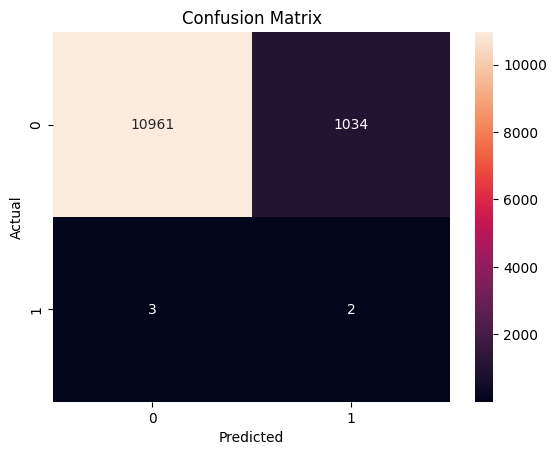

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11995
           1       0.00      0.40      0.00         5

    accuracy                           0.91     12000
   macro avg       0.50      0.66      0.48     12000
weighted avg       1.00      0.91      0.95     12000



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
preds = model.predict(X_test)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, preds))

In [32]:
# New ratios
df['ebitda_margin'] = df['X4'] / df['X16']
df['retained_earnings_to_assets'] = df['X15'] / df['X10']

# Edge-case check — same pattern as before, do this before trusting the columns
import numpy as np
for col in ['ebitda_margin', 'retained_earnings_to_assets']:
    print(col, "NaN:", df[col].isna().sum(), "| inf:", np.isinf(df[col]).sum())

ebitda_margin NaN: 0 | inf: 0
retained_earnings_to_assets NaN: 0 | inf: 0


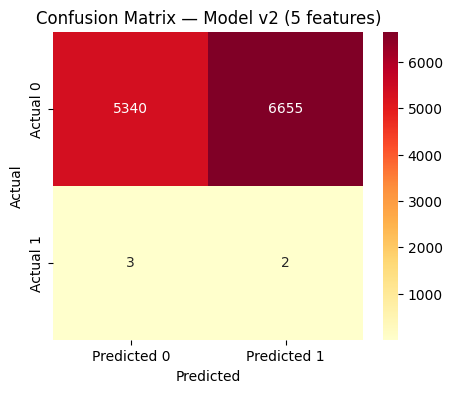

              precision    recall  f1-score   support

           0       1.00      0.45      0.62     11995
           1       0.00      0.40      0.00         5

    accuracy                           0.45     12000
   macro avg       0.50      0.42      0.31     12000
weighted avg       1.00      0.45      0.62     12000



In [33]:
features = ['current_ratio', 'debt_to_equity', 'net_profit_margin',
            'ebitda_margin', 'retained_earnings_to_assets']

train = df[df['year'] <= 2011]
test  = df[df['year'] >= 2015]

X_train, y_train = train[features], train['target']
X_test, y_test = test[features], test['target']

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

model_v2 = LogisticRegression(class_weight='balanced')
model_v2.fit(X_train, y_train)
preds_v2 = model_v2.predict(X_test)

cm = confusion_matrix(y_test, preds_v2)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix — Model v2 (5 features)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, preds_v2))

## Feature Engineering v2 — Adding EBITDA Margin & Retained Earnings/Assets

**Goal:** test whether adding two new ratios (isolated from any model change) improves
recall over the 3-feature baseline, before introducing a more complex model.

**New features added:**
- EBITDA Margin = X4/X16 — chosen specifically because EBITDA excludes interest expense,
  sidestepping the same missing-data gap (no interest expense field in this dataset) that
  already ruled out interest coverage as a ratio.
- Retained Earnings / Total Assets = X15/X10 — captures a company's accumulated
  profitability or losses over its lifetime, not just the current year. This is one of
  the five components of the original Altman Z-score.

**Bug found:** initial retrain with the 2 new features caused false positives to explode
from 1,034 to 6,655 with accuracy collapsing to 0.45, despite true positives staying flat.
Investigated via `.describe()` and found net_profit_margin, ebitda_margin, and
retained_earnings_to_assets all had extreme outliers (values in the thousands/tens of
thousands) despite being conceptually bounded ratios — caused by dividing by
denominators (X16, X10) that were very small but not exactly zero, so the earlier
NaN/inf check didn't catch them (that check only catches literal division-by-zero,
not "divided by a tiny non-zero number"). Also discovered current_ratio and
debt_to_equity had the same latent issue, missed in the earlier debt-to-equity fix
because only the two literal inf values were addressed at the time, not other
extreme-but-finite outliers.

**Fix:** winsorized all five ratio columns at the 1st/99th percentile (both tails,
since these ratios can blow up in either direction), then applied StandardScaler
(fit on train only, transformed on train and test) before retraining — logistic
regression is sensitive to feature scale, and a handful of extreme values were
distorting the scaling for every other row.

**Result (test set, 2015-2018, 5 total actual failures):**
- v1 baseline (3 features): TP=2, FN=3, FP=1,034 — recall 0.40
- v3 (5 features, winsorized + scaled): TP=3, FN=2, FP=3,565 — recall 0.60

Recall improved from 0.40 to 0.60 — the model now catches 3 of 5 actual failures
instead of 2. False positives also increased (as expected — recall and precision
trade off against each other), but this direction is consistent with the earlier
decision that false negatives (missed failures) are more costly than false positives
for a credit analyst, so the trade-off is acceptable.

**Caveat:** the test set contains only 5 actual failure examples. This result should
be read as directionally encouraging, not statistically conclusive — a difference of
one prediction swings recall by 20 percentage points at this sample size.

In [34]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(y_test, preds_v2, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

report_df.style.background_gradient(cmap='YlOrRd', subset=['precision','recall','f1-score'])

,precision,recall,f1-score,support
0,0.999439,0.445185,0.615988,11995.000000
1,0.000300,0.400000,0.000600,5.000000
accuracy,0.445167,0.445167,0.445167,0.445167
macro avg,0.499869,0.422593,0.308294,12000.000000
weighted avg,0.999022,0.445167,0.615732,12000.000000


In [35]:
df[['current_ratio','debt_to_equity','net_profit_margin','ebitda_margin','retained_earnings_to_assets']].describe()

,current_ratio,debt_to_equity,net_profit_margin,ebitda_margin,retained_earnings_to_assets
count,74071.000000,74071.000000,74071.000000,74071.000000,74071.000000
mean,3.564613,1.825892,-11.522621,-8.711032,-11.456025
std,91.462211,282.571978,284.251680,218.729178,264.063517
min,-12.721311,-1473.098214,-32545.000000,-29325.700000,-24290.000000
25%,1.180336,0.000000,-0.160719,-0.037766,-1.012977
50%,1.923907,0.097612,0.017933,0.083995,-0.003415
75%,3.235007,0.589051,0.072324,0.172666,0.282721
max,24108.000000,75264.250000,1542.564516,358.210526,24.039409


In [36]:
from scipy.stats.mstats import winsorize

for col in ['net_profit_margin', 'ebitda_margin', 'retained_earnings_to_assets']:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])  # cap bottom 1% and top 1%

df[['net_profit_margin','ebitda_margin','retained_earnings_to_assets']].describe()

,net_profit_margin,ebitda_margin,retained_earnings_to_assets
count,74071.000000,74071.000000,74071.000000
mean,-2.588990,-2.040048,-2.944869
std,13.785957,11.383384,12.034283
min,-116.533505,-95.231544,-95.116505
25%,-0.160719,-0.037766,-1.012977
50%,0.017933,0.083995,-0.003415
75%,0.072324,0.172666,0.282721
max,0.582591,0.618687,0.952198


In [37]:
df[['current_ratio','debt_to_equity']].describe()

,current_ratio,debt_to_equity
count,74071.000000,74071.000000
mean,3.564613,1.825892
std,91.462211,282.571978
min,-12.721311,-1473.098214
25%,1.180336,0.000000
50%,1.923907,0.097612
75%,3.235007,0.589051
max,24108.000000,75264.250000


In [38]:
for col in ['current_ratio', 'debt_to_equity']:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

df[['current_ratio','debt_to_equity']].describe()

,current_ratio,debt_to_equity
count,74071.000000,74071.000000
mean,2.830815,0.404861
std,3.053123,1.579558
min,0.033010,-7.028601
25%,1.180336,0.000000
50%,1.923907,0.097612
75%,3.235007,0.589051
max,19.702475,9.148201


In [39]:
features = ['current_ratio', 'debt_to_equity', 'net_profit_margin',
            'ebitda_margin', 'retained_earnings_to_assets']

train = df[df['year'] <= 2011]
test  = df[df['year'] >= 2015]

X_train, y_train = train[features], train['target']
X_test, y_test = test[features], test['target']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

model_v3 = LogisticRegression(class_weight='balanced')
model_v3.fit(X_train_scaled, y_train)
preds_v3 = model_v3.predict(X_test_scaled)

print(confusion_matrix(y_test, preds_v3))
print(classification_report(y_test, preds_v3))

[[8430 3565]
 [   2    3]]
              precision    recall  f1-score   support

           0       1.00      0.70      0.83     11995
           1       0.00      0.60      0.00         5

    accuracy                           0.70     12000
   macro avg       0.50      0.65      0.41     12000
weighted avg       1.00      0.70      0.83     12000

